# **CONVOLUTIONAL NEURAL NETWORK (CNN)**
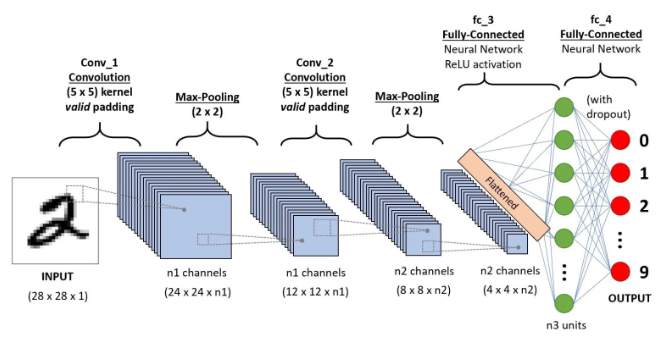


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train = pd.read_csv('/content/sample_data/mnist_train_small.csv')
df_test= pd.read_csv('/content/sample_data/mnist_test.csv')

In [ ]:
df_train.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_test.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
## checking the unique values in the first column.
df_train['6'].unique()

array([5, 7, 9, 2, 0, 6, 8, 3, 4, 1])

In [ ]:
df_test['7'].unique()

array([2, 1, 0, 4, 9, 5, 6, 7, 3, 8])

In [ ]:
## checking the value counts for the values
df_train['6'].value_counts()

,count
6,
1,2243
7,2126
6,2038
9,2023
3,2021
2,1989
0,1962
4,1924
8,1912


In [ ]:
df_test['7'].value_counts()

,count
7,
1,1135
2,1032
7,1027
3,1010
9,1009
4,982
0,980
8,974
6,958


In [ ]:
X_train = df_train.iloc[:, 1:].values   # pixels
y_train = df_train.iloc[:, 0].values    # labels

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

In [ ]:
## normalizing the data(only X_train and X_test has to be normalized)
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train.shape

(19999, 784)

In [ ]:
## basically if we are building models using the images then it is best to use the convolutional neural network(CNN)
## for that we need to reshape the data into the table_size(224*224) with depth (1 or 2 or 100 etc)---> 224*224*1
## it describes that it is 224*224 tensor/matrix/table with 1 dimension depth.

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

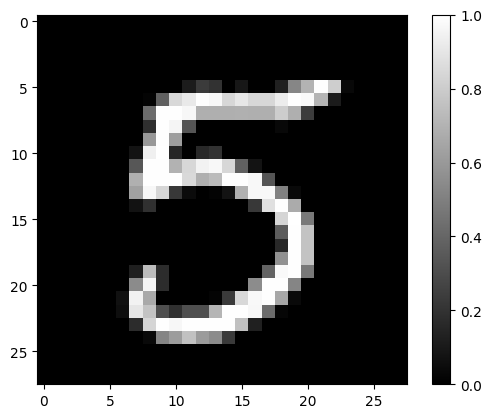

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(28,28),cmap='gray')
plt.colorbar()

In [ ]:
X_train.shape

(19999, 28, 28, 1)

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
## building the cnn model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

In [ ]:
model = Sequential([                                           #Conv2D(  32,           (3,3))
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),  #Conv2D(filters,(sizeofmatrixoffilter))
    MaxPool2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPool2D((2,2)),  # used to extract high-level patterns from the data.
    Flatten(), ## converting in to 1-D array to pass them into fully connected layer.
    Dense(128,activation='relu'),# fully connected layer
    Dense(10,activation='softmax') # output layer.
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()  # model.summary() shows how many layers in the Neural network and output shape of each layer

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(X_train,y_train,epochs=10,validation_split=0.2,batch_size=150)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.9761 - loss: 0.0818 - val_accuracy: 0.9732 - val_loss: 0.0783
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.9826 - loss: 0.0556 - val_accuracy: 0.9778 - val_loss: 0.0651
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.9872 - loss: 0.0434 - val_accuracy: 0.9812 - val_loss: 0.0591
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 142ms/step - accuracy: 0.9896 - loss: 0.0411 - val_accuracy: 0.9815 - val_loss: 0.0533
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.9911 - loss: 0.0297 - val_accuracy: 0.9847 - val_loss: 0.0471
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.9937 - loss: 0.0229 - val_accuracy: 0.9847 - val_loss: 0.0493
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.9956 - loss: 0.0157 - val_accuracy: 0.9883 - val_loss: 0.0407
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.9962 - loss: 0

In [ ]:
test_loss,test_acc = model.evaluate(X_test,y_test)
test_loss,test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9801 - loss: 0.0702


(0.054032012820243835, 0.9855985641479492)

In [ ]:
pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:
import numpy as np
print("actual:",y_test[7])
print("Predicted:",np.argmax(pred[7]))

actual: 5
Predicted: 5
